# Day 3 — Statistics, Returns, Volatility & Correlation

## Goal

Today I am learning how to quantitatively describe stock returns
and compare AAPL's behavior with the broader market.

Topics:
- Daily returns
- Cumulative returns
- Mean and median
- Variance and standard deviation
- Percentiles
- Return distributions
- Volatility
- Rolling volatility
- Correlation
- AAPL vs SPY vs QQQ

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv(
    "../data/raw/AAPL_daily_raw.csv",
    index_col="Date",
    parse_dates=True
)

data.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,daily_return
Date,,,,,,,,,
2015-01-02 00:00:00-05:00,27.847500,27.860001,26.837500,27.332500,24.171755,212818400,0.0,0.0,NaN
2015-01-05 00:00:00-05:00,27.072500,27.162500,26.352501,26.562500,23.490799,257142000,0.0,0.0,-0.028172
2015-01-06 00:00:00-05:00,26.635000,26.857500,26.157499,26.565001,23.493013,263188400,0.0,0.0,0.000094
2015-01-07 00:00:00-05:00,26.799999,27.049999,26.674999,26.937500,23.822430,160423600,0.0,0.0,0.014022
2015-01-08 00:00:00-05:00,27.307501,28.037500,27.174999,27.972500,24.737757,237458000,0.0,0.0,0.038423


In [12]:
data["daily_return"] = data["Adj Close"].pct_change()
data[["Adj Close", "daily_return"]].head(10)

,Adj Close,daily_return
Date,,
2015-01-02 00:00:00-05:00,24.171755,NaN
2015-01-05 00:00:00-05:00,23.490799,-0.028172
2015-01-06 00:00:00-05:00,23.493013,0.000094
2015-01-07 00:00:00-05:00,23.822430,0.014022
2015-01-08 00:00:00-05:00,24.737757,0.038423
2015-01-09 00:00:00-05:00,24.764284,0.001072
2015-01-12 00:00:00-05:00,24.154066,-0.024641
2015-01-13 00:00:00-05:00,24.368534,0.008879
2015-01-14 00:00:00-05:00,24.275665,-0.003811


In [14]:
returns = data["daily_return"].dropna()
returns.head()

Date
2015-01-05 00:00:00-05:00   -0.028172
2015-01-06 00:00:00-05:00    0.000094
2015-01-07 00:00:00-05:00    0.014022
2015-01-08 00:00:00-05:00    0.038423
2015-01-09 00:00:00-05:00    0.001072
Name: daily_return, dtype: float64

In [15]:
returns.shape

(2765,)

In [20]:
mean_return = returns.mean()

mean_return = mean_return * 100
print(f"{mean_return:.2f}%")

0.10%


In [28]:
median_return = returns.median()

median_return = median_return * 100
print(f"{median_return:.2f}%")

0.10%


In [30]:
daily_std = returns.std()


daily_std = daily_std * 100
print(f"{daily_std:.2f}%")

1.82%


In [33]:
variance = returns.var()

daily_var = daily_std ** 2
print(f"{daily_var:.2f}%")

3.30%


In [35]:
returns.describe()

count    2765.000000
mean        0.001039
std         0.018171
min        -0.128647
25%        -0.007282
50%         0.000951
75%         0.010015
max         0.153289
Name: daily_return, dtype: float64

In [39]:
returns.quantile(0.99)

np.float64(0.04944744974253762)

In [40]:
percentiles = returns.quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

percentiles * 100

0.01   -4.807305
0.05   -2.720149
0.25   -0.728223
0.50    0.095075
0.75    1.001452
0.95    2.837197
0.99    4.944745
Name: daily_return, dtype: float64

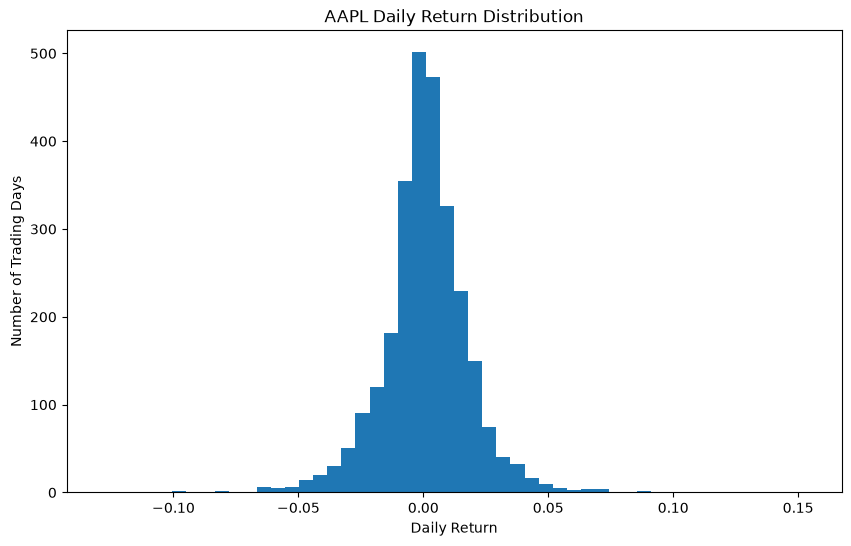

In [41]:
plt.figure(figsize=(10, 6))

plt.hist(
    returns,
    bins=50
)

plt.title("AAPL Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Number of Trading Days")

plt.show()

In [42]:
returns.nsmallest(10)

Date
2020-03-16 00:00:00-04:00   -0.128647
2019-01-03 00:00:00-05:00   -0.099607
2020-03-12 00:00:00-04:00   -0.098755
2025-04-03 00:00:00-04:00   -0.092456
2020-09-03 00:00:00-04:00   -0.080061
2020-03-09 00:00:00-04:00   -0.079092
2025-04-04 00:00:00-04:00   -0.072887
2020-09-08 00:00:00-04:00   -0.067295
2018-11-02 00:00:00-04:00   -0.066331
2016-01-27 00:00:00-05:00   -0.065706
Name: daily_return, dtype: float64

In [43]:
returns.nlargest(10)

Date
2025-04-09 00:00:00-04:00    0.153289
2020-03-13 00:00:00-04:00    0.119808
2020-07-31 00:00:00-04:00    0.104689
2020-03-24 00:00:00-04:00    0.100326
2020-03-02 00:00:00-05:00    0.093101
2022-11-10 00:00:00-05:00    0.088975
2020-04-06 00:00:00-04:00    0.087238
2022-10-28 00:00:00-04:00    0.075553
2024-06-11 00:00:00-04:00    0.072649
2020-03-10 00:00:00-04:00    0.072022
Name: daily_return, dtype: float64

In [45]:
data["cumulative_return"] = (1 + data["daily_return"]).cumprod() - 1
data[["daily_return", "cumulative_return"]].tail()

,daily_return,cumulative_return
Date,,
2025-12-24 00:00:00-05:00,0.005324,10.296934
2025-12-26 00:00:00-05:00,-0.001497,10.280018
2025-12-29 00:00:00-05:00,0.001317,10.294872
2025-12-30 00:00:00-05:00,-0.002484,10.266815
2025-12-31 00:00:00-05:00,-0.004468,10.216480


In [48]:
data["cumulative_return"].iloc[-1]
print(f'{data["cumulative_return"].iloc[-1] * 100:.2f}%')

1021.65%


In [49]:
print(f'{data["cumulative_return"].iloc[-1] * 100:.2f}%')

1021.65%


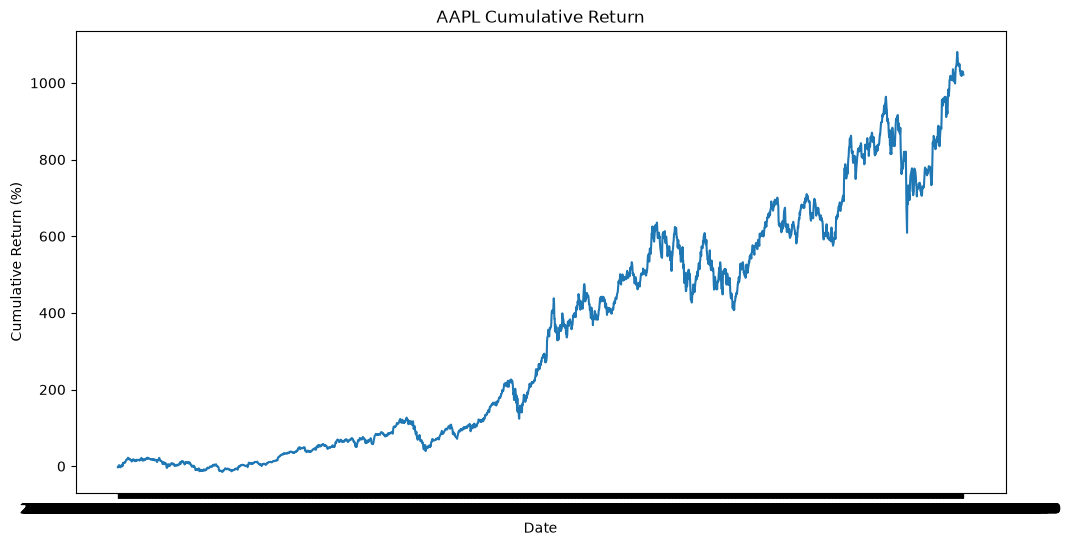

In [50]:
plt.figure(figsize=(12, 6))

plt.plot(
    data.index,
    data["cumulative_return"] * 100
)

plt.title("AAPL Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")

plt.show()

In [52]:
daily_volatility = returns.std()
annualized_volatility = (daily_volatility * np.sqrt(252))

annualized_volatility * 100

np.float64(28.845810640196152)

In [ ]:
annualized_volatility = (daily_volatility * np.sqrt(252))

annualized_volatility * 100

In [53]:
data["rolling_20d_volatility"] = (
    data["daily_return"]
    .rolling(20)
    .std()
)

In [54]:
data[
    [
        "daily_return",
        "rolling_20d_volatility"
    ]
].tail(20)

,daily_return,rolling_20d_volatility
Date,,
2025-12-03 00:00:00-05:00,-0.007128,0.010105
2025-12-04 00:00:00-05:00,-0.012141,0.010627
2025-12-05 00:00:00-05:00,-0.006840,0.010788
2025-12-08 00:00:00-05:00,-0.003192,0.010742
2025-12-09 00:00:00-05:00,-0.002555,0.010765
2025-12-10 00:00:00-05:00,0.005772,0.009740
2025-12-11 00:00:00-05:00,-0.002690,0.009630
2025-12-12 00:00:00-05:00,0.000899,0.009608
2025-12-15 00:00:00-05:00,-0.014985,0.010241


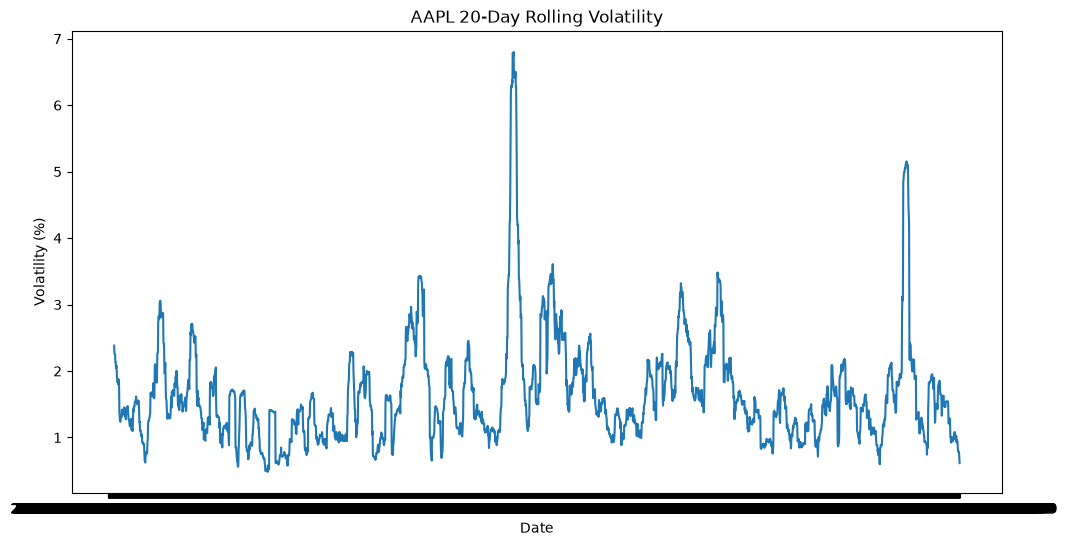

In [58]:
plt.figure(figsize=(12, 6))

plt.plot(
    data.index,
    data["rolling_20d_volatility"] * 100
)

plt.title("AAPL 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")

plt.show()

In [59]:
import yfinance as yf

spy = yf.Ticker("SPY").history(
    start="2015-01-01",
    end="2026-01-01",
    interval="1d",
    prepost=False,
    auto_adjust=False
)

qqq = yf.Ticker("QQQ").history(
    start="2015-01-01",
    end="2026-01-01",
    interval="1d",
    prepost=False,
    auto_adjust=False
)

voo = yf.Ticker("VOO").history(
    start="2015-01-01",
    end="2026-01-01",
    interval="1d",
    prepost=False,
    auto_adjust=False 
)

In [78]:
qqq.tail()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains,daily_return
Date,,,,,,,,,,
2025-12-24 00:00:00-05:00,621.989990,624.280029,621.719971,623.929993,621.812317,18468700,0.0,0.0,0.0,0.002926
2025-12-26 00:00:00-05:00,624.659973,625.520020,623.140015,623.890015,621.772400,28959800,0.0,0.0,0.0,-0.000064
2025-12-29 00:00:00-05:00,620.099976,622.780029,618.729980,620.869995,618.762634,32458300,0.0,0.0,0.0,-0.004841
2025-12-30 00:00:00-05:00,619.840027,622.179993,619.219971,619.429993,617.327515,31226800,0.0,0.0,0.0,-0.002319
2025-12-31 00:00:00-05:00,619.650024,619.960022,614.049988,614.309998,612.224915,40746500,0.0,0.0,0.0,-0.008266


In [60]:
spy["daily_return"] = spy["Adj Close"].pct_change()

qqq["daily_return"] = qqq["Adj Close"].pct_change()

voo["daily_return"] = voo["Adj Close"].pct_change()

In [90]:
data.index = pd.to_datetime(data.index, utc=True)

spy.index = pd.to_datetime(spy.index, utc=True)
qqq.index = pd.to_datetime(qqq.index, utc=True)
voo.index = pd.to_datetime(voo.index, utc=True)

In [87]:
print(type(data.index))
print(data.index[:3])

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2015-01-02 05:00:00+00:00', '2015-01-05 05:00:00+00:00',
               '2015-01-06 05:00:00+00:00'],
              dtype='datetime64[us, UTC]', name='Date', freq=None)


In [91]:
return_data = pd.concat(
    [
        data["daily_return"].rename("AAPL"),
        spy["daily_return"].rename("SPY"),
        qqq["daily_return"].rename("QQQ"),
        voo["daily_return"].rename("VOO")
    ],
    axis=1
)

print(return_data.shape)
print(return_data.isna().sum())

(2766, 4)
AAPL    1
SPY     1
QQQ     1
VOO     1
dtype: int64


In [92]:
return_data = return_data.dropna()

return_data.corr()

,AAPL,SPY,QQQ,VOO
AAPL,1.000000,0.747801,0.802345,0.746546
SPY,0.747801,1.000000,0.933780,0.998828
QQQ,0.802345,0.933780,1.000000,0.932408
VOO,0.746546,0.998828,0.932408,1.000000


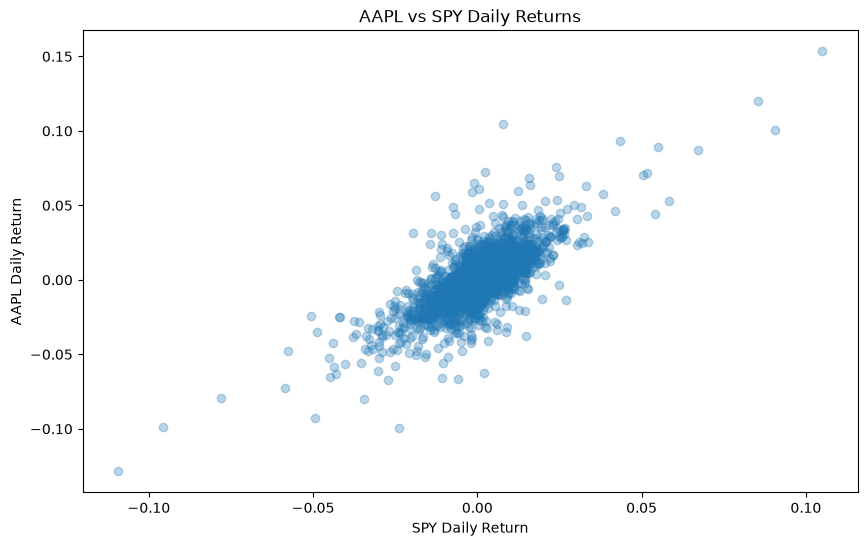

In [94]:
plt.figure(figsize=(10, 6))

plt.scatter(
    return_data["SPY"],
    return_data["AAPL"],
    alpha=0.3
)

plt.title("AAPL vs SPY Daily Returns")
plt.xlabel("SPY Daily Return")
plt.ylabel("AAPL Daily Return")

plt.show()

In [95]:
return_data[["AAPL", "SPY"]].corr()

,AAPL,SPY
AAPL,1.000000,0.747801
SPY,0.747801,1.000000


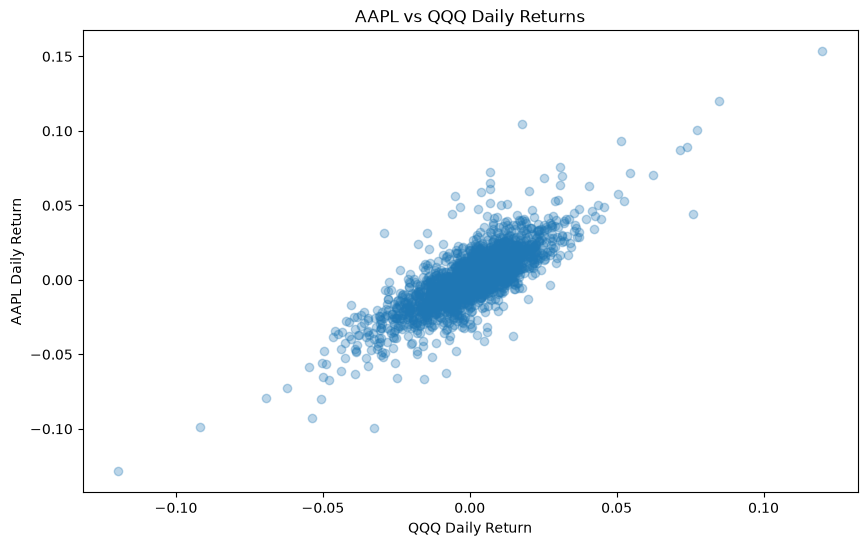

In [96]:
plt.figure(figsize=(10, 6))

plt.scatter(
    return_data["QQQ"],
    return_data["AAPL"],
    alpha=0.3
)

plt.title("AAPL vs QQQ Daily Returns")
plt.xlabel("QQQ Daily Return")
plt.ylabel("AAPL Daily Return")

plt.show()

In [97]:
return_data[["AAPL", "QQQ"]].corr()

,AAPL,QQQ
AAPL,1.000000,0.802345
QQQ,0.802345,1.000000


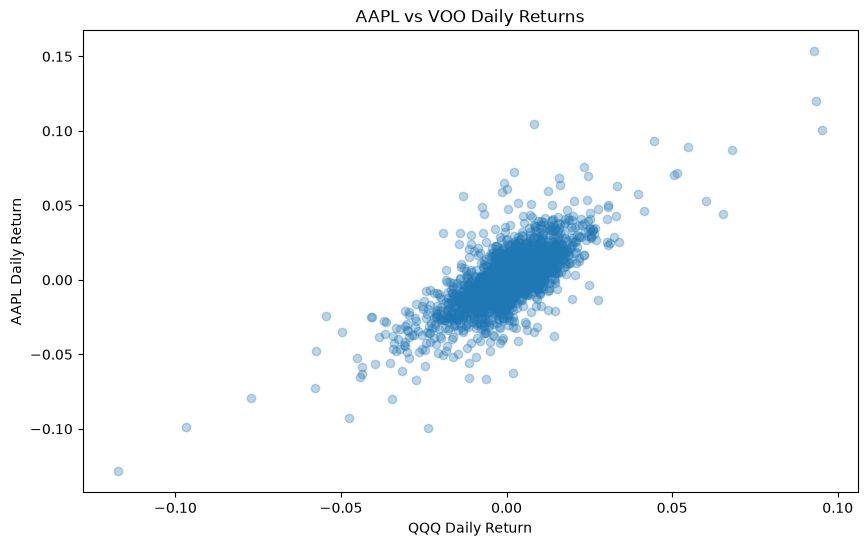

In [100]:
plt.figure(figsize=(10, 6))

plt.scatter(
    return_data["VOO"],
    return_data["AAPL"],
    alpha=0.3
)

plt.title("AAPL vs VOO Daily Returns")
plt.xlabel("QQQ Daily Return")
plt.ylabel("AAPL Daily Return")

plt.show()

In [101]:
return_data[["AAPL", "VOO"]].corr()

,AAPL,VOO
AAPL,1.000000,0.746546
VOO,0.746546,1.000000


In [102]:
summary = pd.DataFrame({
    "Metric": [
        "Mean Daily Return",
        "Median Daily Return",
        "Daily Volatility",
        "Annualized Volatility",
        "1st Percentile Return",
        "99th Percentile Return",
        "Cumulative Return"
    ],
    "Value": [
        returns.mean(),
        returns.median(),
        returns.std(),
        returns.std() * np.sqrt(252),
        returns.quantile(0.01),
        returns.quantile(0.99),
        data["cumulative_return"].iloc[-1]
    ]
})

summary

,Metric,Value
0,Mean Daily Return,0.001039
1,Median Daily Return,0.000951
2,Daily Volatility,0.018171
3,Annualized Volatility,0.288458
4,1st Percentile Return,-0.048073
5,99th Percentile Return,0.049447
6,Cumulative Return,10.216480


In [103]:
summary["Percentage"] = summary["Value"] * 100

summary

,Metric,Value,Percentage
0,Mean Daily Return,0.001039,0.103949
1,Median Daily Return,0.000951,0.095075
2,Daily Volatility,0.018171,1.817115
3,Annualized Volatility,0.288458,28.845811
4,1st Percentile Return,-0.048073,-4.807305
5,99th Percentile Return,0.049447,4.944745
6,Cumulative Return,10.216480,1021.648019


In [105]:
data[
    "daily_return"
].dropna().describe()

count    2765.000000
mean        0.001039
std         0.018171
min        -0.128647
25%        -0.007282
50%         0.000951
75%         0.010015
max         0.153289
Name: daily_return, dtype: float64